# 🧠🤖 Treinamento de Redes Convolucionais

- **Deadline**: 23/12/2025
- **Entrega**: O trabalho deve ser entregue via sistema Testr.
- **Pontuação**: 10 pontos (+1 ponto extra).
- O trabalho deve ser realizado individualmente.



## Especificação


### Contexto

O trabalho consiste em realizar o treinamento de redes neurais convolucionais na base de dados [Chest X-ray Image (COVID19, PNEUMONIA, and NORMAL) disponível no kaggle](https://www.kaggle.com/datasets/alsaniipe/chest-x-ray-image). Esta base de dados contém exames de raio-x de pacientes saudáveis, com pneumonia e com covid19. O objetivo do trabalho é treinar uma rede neural capaz de identificar se o raio-x pertence a uma pessoa saudável ou com uma das duas doenças.




### Regras

- Devem ser treinadas 3 redes neurais, uma customizada (desenvolvida pelo aluno), uma pré-treinada com parte convolucional congelada e uma pré-treinada  treinada totalmente (*fine-tuning*).
- O dataset provê conjuntos de treino e teste. O conjunto de treino deve ser dividido em treino e validação.
- O código deve ser preparado para utilizar GPUs (no colab ou localmente).
- Não devem ser utilizados frameworks de alto nível como keras ou lightning. O código deve utilizar apenas pytorch.
- Deve ser utilizado data augmentation (o aluno tem liberdade para escolher os métodos que fizerem sentido para a tarefa).
- Ao final, deve ser apresentados gráficos comparando as acurácias de treino e validação ao longo das épocas e uma tabela apresentando as métricas de performance revocação, f1-score e acurácia para o conjunto de teste em cada configuração de rede neural. Além disso, deve ser uma análise qualitativa dos casos de falha.
- Por fim, deve ser escrito um texto curto descrevendo e discutindo os resultados. Deve ser explicado com as suas palavras o que as métricas indicam (e.g., o que quer dizer um recall alto para pneumonia, se isto acontecer), se aconteceu overfitting ou se o modelo alcançou uma boa generalização, se os valores das métricas foram satisfatórios, prováveis causas para as falhas e sugestões de como melhorar a performance.



### Pontos Extras

- Receberá um ponto extra, o aluno que utilizar um método explainability (e.g., [gradcam++](https://github.com/jacobgil/pytorch-grad-cam)) para mostrar as regiões que mais influenciaram a decisão da rede neural.


### Dicas de Implementação

- **Download dos dados**: use a biblioteca `kagglehub` para fazer o download do dataset no colab.

- **Criação do dataset**: o pytorch possui a função [ImageFolder](https://debuggercafe.com/pytorch-imagefolder-for-training-cnn-models/) que torna mais simples a criação de datasets organizados no formato do dataset utilizado no trabalho.

- **Leitura e preprocessamento das Imagens**: As imagens do dataset possuem características bastante diversas, com algumas delas sendo armazenadas em tons de cinza e outras em RGB, algumas são arquivos BITMAP armazenados em formato jpg, algumas usam 8 bits e outras 16 bits para representar pixels e as resoluções das imagens são altamente diferentes. Use a função abaixo para ler as imagens e lembre-se de realizar *resize* para o tamanho esperado pela rede neural.

```python
from PIL import Image

def load_img(path):
  # Le a imagem em diversos formatos e garante que a imagem tenha 3 canais
  img = Image.open(path).convert('RGB')
  # converte para um tensor do pytorch
  img = v2.functional.to_image(img)
  # garante que seja uma imagem de 8 bits reescalando os valores adequadamente
  img = v2.functional.to_dtype(img, dtype=torch.uint8, scale=True)
  return img
```

- **Aumento de Dados**: Para visualizar a maioria das transformações disponíveis, veja [este site](https://docs.pytorch.org/vision/main/auto_examples/transforms/plot_transforms_illustrations.html). Use a versão `v2` do pacote `pytorch.transforms`. Veja [este link](https://docs.pytorch.org/vision/main/transforms.html#v2-api-reference-recommended) para uma explicação do porquê e instruções de uso.
  - ⚠️**IMPORTANTE**⚠️: o aumento de dados deve ser aplicado apenas no conjunto de treinamento para aumentar a diversidade dos dados. Os dados de validação e teste devem ser **puros e não modificados**, exceto por operações como resize ou normalização.


- **Seleção de um modelo pré-treinado**: É uma boa idéia experimentar com diferentes modelos pré-treinados para avaliar qual vai levar a predições mais corretas e avaliar outros critérios, por exemplo, tempo de forward por imagem. Uma heurística para escolher modelos é buscar aqueles que possuem [melhor performance na base de dados ImageNet](https://docs.pytorch.org/vision/0.21/models.html#table-of-all-available-classification-weights:~:text=Table%20of%20all%20available%20classification%20weights).
  - As redes mobilenet-v2 e -v3 são desenhadas para serem rápidas e rodarem em dispositivos de baixo poder computacional.
  - A rede densenet em geral entrega boa performance.
  - As Efficientnet-b5+ não rodam no colab (até a última vez que testei) por falta de memória.
  - As redes ViT usam a arquitetura transformers e não são convolucionais. **Elas podem ser utilizadas para comparação, mas pelo menos uma outra rede neural totalmente convolucional deve ser utilizada**.

- **Visualize sempre que possível**: Não deixe de visualizar pelo menos uma vez os batches que estão sendo usados para treinar a rede. Alguma operação pode estar transformando as imagens de forma que a impedir que a rede neural seja capaz de aprender os padrões que ela deveria aprender.

- **Brinque com Hiperparâmetros**: Ajuste os hiperparâmetros para tentar chegar em modelos com o máximo de performance de validação. Não é obrigatório, mas é legal brincar também com técnicas de regularização, caso a rede esteja sofrendo de overfitting.

- **Desbalanceamento do Dataset**: O dataset possui algum nível de desbalanceamento, com mais imagens normais do que com covid ou pneumonia. Não é obrigatório, mas quem quiser pode realizar superamostragem dos dados com covid ou pneumonia para mitigar o desbalanceamento. As operações de data augmentation vão garantir que os dados tenham diversidade.


- **Escrita de tabelas**: Tabelas podem ser escritas em notebooks usando latex, como indicado abaixo.

```latex
\begin{array}{ccc}
\hline
modelo & métrica1 & métrica2 \\ \hline
custom & 0.85 & 0.83 \\ \hline
frozen-conv & 0.91 & 0.92 \\ \hline
fine-tuning & 0.93 & 0.90 \\ \hline
\end{array}
```

O resultado seria:

\begin{array}{ccc}
\hline
modelo & métrica1 & métrica2 \\ \hline
custom & 0.85 & 0.83 \\ \hline
frozen-conv & 0.91 & 0.92 \\ \hline
fine-tuning & 0.93 & 0.90 \\ \hline
\end{array}

Elas também pode ser escritas em markdown como indicado abaixo:

```markdown
| modelo | métrica1 | métrica2 |
|---|---|---|
| custom | 0.85 | 0.83 |
| frozen-conv | 0.91 | 0.92 |
| fine-tuning | 0.93 | 0.90 |
```

O resultado seria:

| modelo | métrica1 | métrica2 |
|---|---|---|
| custom | 0.85 | 0.83 |
| frozen-conv | 0.91 | 0.92 |
| fine-tuning | 0.93 | 0.90 |


### Roteiro de Implementação

Para realizar o trabalho, siga os seguintes passos:

1. Faça o download automático do dataset.
1. Compreenda a organização do dataset e visualize alguns dados.
1. Crie os dataset de treino, validação e teste do pytorch. Visualize se os dados continuam com a mesma cara.
1. Crie as transformações de data augmentation e adicione ao dataset de treino.
1. Crie transformações para os datasets de validação e teste que coloquem os dados no mesmo formato usado no treino, por exemplo, resize e normalização. Lembre-se de **NÃO** aplicar data augmentation nos conjuntos de validação e teste!
1. Crie dataloaders.
1. Construa uma CNN.
1. Escreva funções para treinamento e avaliação. Retorne o valor da acurácia para os conjuntos de treino e validação nas épocas de treinamento.
1. Crie uma loss function e um otimizador.
1. Execute o treinamento e verifique se a curva de treinamento está se comportando como esperado.
  - A acurácia de treinamento está aumentando? Se não, verifique se o dataset está certo e aumente a capacidade da rede.
  - A acurácia de treinamento se aproximando de 100%? Se não, aumente a capacidade da rede e tente ajustar a learning rate.
  - A acurácia de validação está aumentando no início do treinamento? Se não, verifique se os dados de validação estão no mesmo formato dos dados de treinamento.
  - A acurácia de validação está diminuindo depois de um número de épocas? Parece que está acontecendo overfitting. Tente usar algum método de regularização.  
1. Brinque com os hiperparâmetros para tentar fazer a rede aprender mais rápido e com maior performance de validação.
1. Crie uma função para calcular métricas de avaliação e visualize as métricas para os conjuntos de treinamento e teste. Compare os dois e veja se aconteceu overiffitting.

Repita o processo usando as redes pré-treinadas.



# Implementação Parte 1

## Imports

In [ ]:
!git clone https://github.com/paaatcha/raug.git

Cloning into 'raug'...
remote: Enumerating objects: 922, done.
remote: Counting objects: 100% (143/143), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 922 (delta 88), reused 98 (delta 51), pack-reused 779 (from 1)
Receiving objects: 100% (922/922), 229.47 KiB | 9.98 MiB/s, done.
Resolving deltas: 100% (567/567), done.


In [ ]:
!pip install -q tensorboardX python-telegram-bot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.0/731.0 kB 22.4 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import kagglehub
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split, KFold
from collections import Counter
from torch.utils.data import Subset
import torch
import torch.nn as nn
import torch.nn.functional as F
from raug.raug.train import fit_model
from raug.raug.eval import test_model
import time
from torchvision import models
from google.colab import drive

/content/raug/raug/train.py:353: SyntaxWarning: invalid escape sequence '\-'
  new_best_print = '\-- New best {}: {:.3f}'.format(best_metric, best_metric_value)


## Download Imagens

In [ ]:
path = kagglehub.dataset_download("alsaniipe/chest-x-ray-image")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-x-ray-image' dataset.
Path to dataset files: /kaggle/input/chest-x-ray-image


## Amostra de Imagens

In [ ]:
Imagens = datasets.ImageFolder( root=os.path.join(path, 'Data/train'))

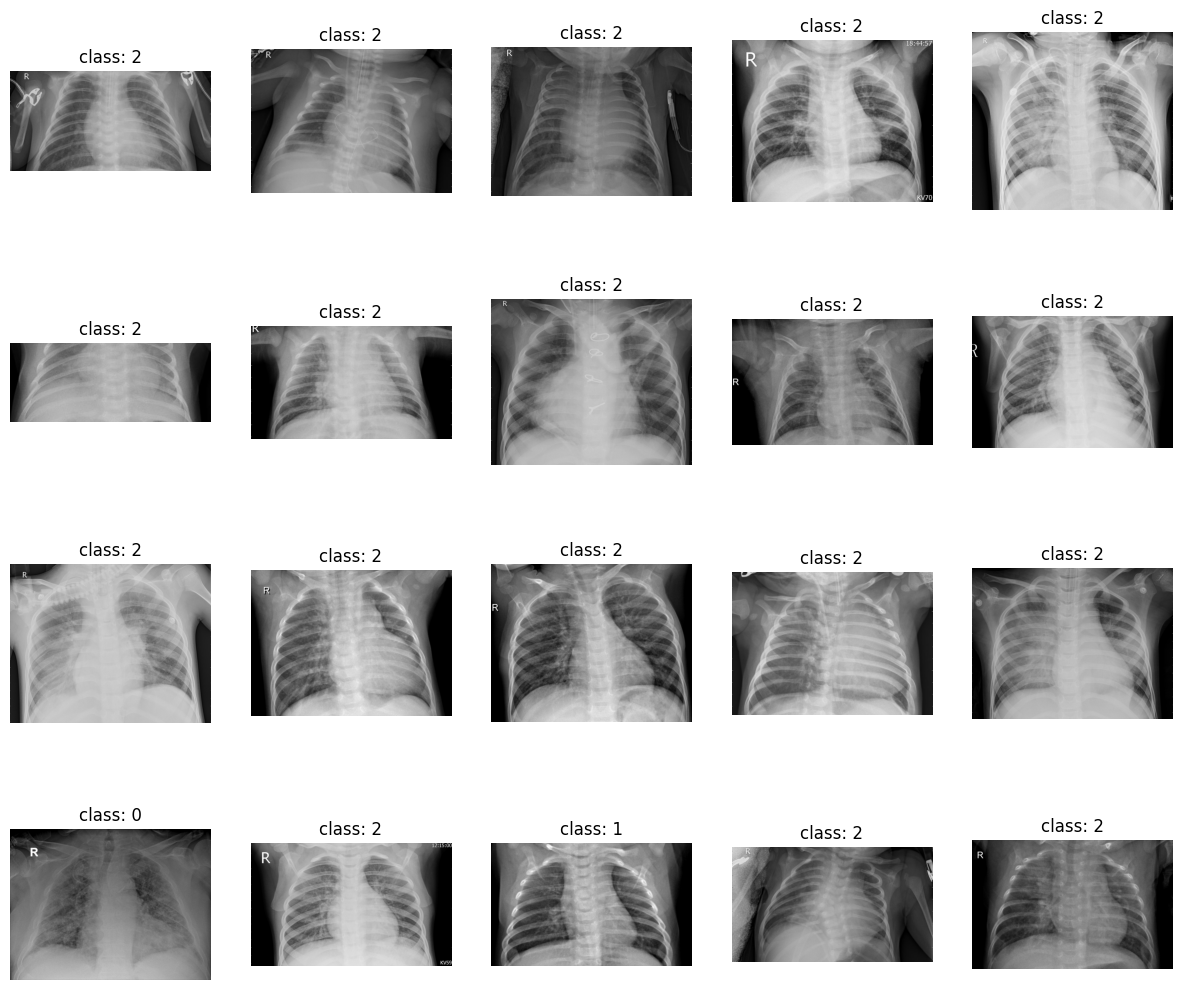

In [ ]:
Imagens = datasets.ImageFolder( root=os.path.join(path, 'Data/train'))

plt.figure(figsize=(15, 13))
for idx in range(20):
  random_idx = np.random.randint(0, len(Imagens)-1)
  image, label = Imagens[random_idx]
  plt.subplot(4, 5, idx+1)
  plt.imshow(image)
  plt.grid(False)
  plt.axis('off')
  plt.title(f"class: {label}")

plt.show()

## Criando Dataset

### Transforms

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    # Data Augmentation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomResizedCrop(
        size=224,
        scale=(0.9, 1.0)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

normal_transform = transforms.Compose([
    transforms.Resize((224, 224)), # A SER CORRIGIDO SE NECESSÁRIO
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], # A SER CORRIGIDO SE NECESSÁRIO
        std=[0.229, 0.224, 0.225]  # A SER CORRIGIDO SE NECESSÁRIO
    )
])

In [ ]:
#  CRIANDO DATASETS --------------------------------

train_dataset = datasets.ImageFolder(
    root=os.path.join(path, 'Data/train'),
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(path, 'Data/test'),
    transform=normal_transform
)

targets = [label for _, label in train_dataset.samples]

train_idx, val_idx = train_test_split(
    np.arange(len(targets)),
    test_size=0.2,
    stratify=targets,
    random_state=42
)

train_subset = Subset(train_dataset, train_idx)
val_subset = Subset(train_dataset, val_idx)


# CRIANDO LOADERS --------------------------------------------------

test_loader = DataLoader(
    test_dataset,
    batch_size=32, # A SER ALTERADO SE NECESSÁRIO
    shuffle=False, # A SER ALTERADO SE NECESSÁRIO
    num_workers=2
)

#  CONFERINDO DATASETS ---------------------------------------------

print(train_dataset.classes)
print(len(train_dataset.classes))
print(train_dataset.class_to_idx)

print("\n") # -----------------------------------------------------

img, label = train_dataset[0]

print(img.shape)
print(label)

print("\n") # -------------------------------------------------------

train_labels = [train_dataset.samples[i][1] for i in train_idx]
val_labels = [train_dataset.samples[i][1] for i in val_idx]

print("Treino:", Counter(train_labels))
print("Validação:", Counter(val_labels))

['COVID19', 'NORMAL', 'PNEUMONIA']
3
{'COVID19': 0, 'NORMAL': 1, 'PNEUMONIA': 2}


torch.Size([3, 224, 224])
0


Treino: Counter({2: 2734, 1: 1013, 0: 368})
Validação: Counter({2: 684, 1: 253, 0: 92})


## Construindo CNN

In [ ]:
class MyCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(MyCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [ ]:
device = torch.accelerator.current_accelerator().type \
  if torch.accelerator.is_available() else "cpu"

model = MyCNN(num_classes=3).to(device)

x = torch.randn(1, 3, 224, 224).to(device)
y = model(x)

print(y.shape)  # esperado: [1, 3]

torch.Size([1, 3])


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)


NameError: name 'model' is not defined

In [ ]:
def run_kfold_training(
    full_dataset,
    model,
    k_splits=5,
    batch_size=16,
    num_epochs=50,
    save_root="./kfold_results",
    loss_fn=None,
    lr=1e-3,
    metric_to_select="loss",
    Parcial_TF= False,
    Full_TF = False
):
    """
    K-fold para treino e validação.
    O dataset é uma LISTA de amostras, não um Dataset do PyTorch.
    """

    os.makedirs(save_root, exist_ok=True)

    kfold = KFold(n_splits=k_splits, shuffle=True, random_state=42)

    fold_scores = {}   # guardará o valor da melhor métrica de cada fold

    for fold, (train_idx, val_idx) in enumerate(kfold.split(full_dataset)):
        print(f"\n==============================")
        print(f"Iniciando FOLD {fold+1}/{k_splits}")
        print("==============================\n")

        # Cria subsets de acordo com os índices
        train_subset = Subset(full_dataset, train_idx)
        val_subset = Subset(full_dataset, val_idx)

        # # Recria datasets com transformações corretas
        # train_subset.dataset.transform = transform_input
        # val_subset.dataset.transform = transform_input

        # Loaders
        train_loader = DataLoader(
            train_subset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=2
        )
        val_loader = DataLoader(
            val_subset,
            batch_size=32,
            shuffle=False,
            num_workers=2
        )

        if Parcial_TF:
            for param in model.parameters():
                param.requires_grad = False

            for param in model.fc.parameters():
                param.requires_grad = True
            optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
        elif Full_TF:
            parametros_not_fc = [param for param in set(net.parameters()) if param not in set(net.fc.parameters())]
            optimizer = optim.Adam([{'params': parametros_not_fc, 'lr': 1e-x}, {'params': net.fc.parameters(), 'lr': 1e-y}])
        else:
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5)

        # Config pasta do fold
        fold_path = os.path.join(save_root, f"fold_{fold+1}")
        os.makedirs(fold_path, exist_ok=True)

        # Treino
        fit_model(
            model=model,
            train_data_loader=train_loader,
            val_data_loader=val_loader,
            optimizer=optimizer,
            loss_fn=loss_fn,
            epochs=num_epochs,
            epochs_early_stop=3,
            save_folder=fold_path,
            device=None,
            schedule_lr=scheduler,
            model_name=f"model_fold_{fold+1}",
            history_plot=True,
            best_metric=metric_to_select,
        )

        # =====================================================
        # LÊ A MÉTRICA FINAL DO FOLD (BEST)
        # =====================================================
        history_dir = os.path.join(fold_path, "history")

        if metric_to_select == "loss":
            csv_path = os.path.join(history_dir, "val_loss.csv")
            values = np.loadtxt(csv_path)
            best_value = float(np.min(values))
        else:
            csv_path = os.path.join(history_dir, "val_acc.csv")
            values = np.loadtxt(csv_path)
            best_value = float(np.max(values))

        fold_scores[fold + 1] = best_value

        print(f"📌 Fold {fold+1} — melhor {metric_to_select}: {best_value}")

    # ============================================================
    # ESCOLHE O MELHOR FOLD
    # ============================================================
    if metric_to_select == "loss":
        best_fold = min(fold_scores, key=fold_scores.get)
    else:
        best_fold = max(fold_scores, key=fold_scores.get)

    print("\n=======================================")
    print(f"🏆 MELHOR FOLD: {best_fold}")
    print(f"🏅 Métrica [{metric_to_select}]: {fold_scores[best_fold]}")
    print("=======================================\n")

    # caminho para o melhor modelo encontrado
    best_model_ckpt = os.path.join(
        save_root,
        f"fold_{best_fold}",
        "best-checkpoint",
        "best-checkpoint.pth"
    )

    return best_fold, best_model_ckpt

## Treino CNN Construida

In [ ]:
drive.mount('/content/drive')

In [ ]:
BATCH_SIZE = 16
EPOCHS = 10
LR_INIT = 1e-3
K_SPLITS = 3
SAVE_FOLDER = f"/content/drive/MyDrive/Trab2_redes/results_MyCNN/kfold_{int(time.time())}"
LOSS_FN = nn.CrossEntropyLoss()
NUM_CLASSES = len(train_dataset.classes)

INFO:Train-Logger:Starting the training phase
INFO:Train-Logger:Early stopping is set using the number of epochs without improvement
INFO:Train-Logger:The model will be trained from scratch
INFO:Train-Logger:The training will be carry out using 1 GPU:
INFO:Train-Logger:Tesla T4



Iniciando FOLD 1/3

Training...


Epoch 1/10: 100%|#####################################| 215/215 [01:05<00:00,  3.29it/s, loss=0.332]



Evaluating...


100%|###################################################| 54/54 [00:30<00:00,  1.76it/s, loss=0.349]
INFO:Train-Logger:Metrics for epoch 1 out of 10
- Train
-- Loss: 0.332
-- Acc: 89.448
-- Top 2 acc: 98.314

- Validation
-- Loss: 0.349
-- Acc: 89.410
-- Top 2 acc: 98.090
-- Balanced accuracy: 0.829
-- AUC: 0.967

- Training info
-- Early stopping counting: 0 max to stop is 3
-- Current LR: 0.001
-- New best loss: 0.349
-- Best loss so far: 0.349 on epoch 1



...

Training...


Epoch 10/10: 100%|####################################| 215/215 [01:03<00:00,  3.37it/s, loss=0.190]



Evaluating...


100%|###################################################| 54/54 [00:30<00:00,  1.76it/s, loss=0.105]
INFO:Train-Logger:Metrics for epoch 10 out of 10
- Train
-- Loss: 0.190
-- Acc: 93.256
-- Top 2 acc: 99.390

- Validation
-- Loss: 0.105
-- Acc: 96.611
-- Top 2 acc: 99.537
-- Balanced accuracy: 0.951
-- AUC: 0.995

- Training info
-- Early stopping counting: 0 max to stop is 3
-- Current LR: 0.001
-- New best loss: 0.105
-- Best loss so far: 0.105 on epoch 10



Saving history plots in /results_cv/kfold_1766272521/fold_3/history
Saving history CSVs in /results_cv/kfold_1766272521/fold_3/history


📌 Fold 3 — melhor loss: 0.105

🏆 MELHOR FOLD: 3
🏅 Métrica [loss]: 0.105

🏆 Melhor fold: 3
📁 Melhor modelo: /results_cv/kfold_1766272521/fold_3/best-checkpoint/best-checkpoint.pth


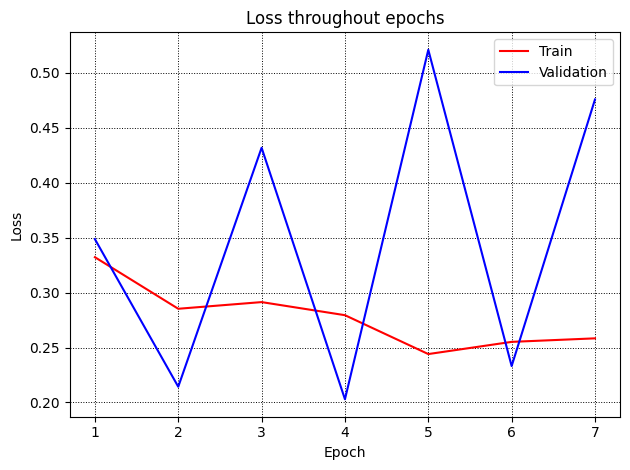

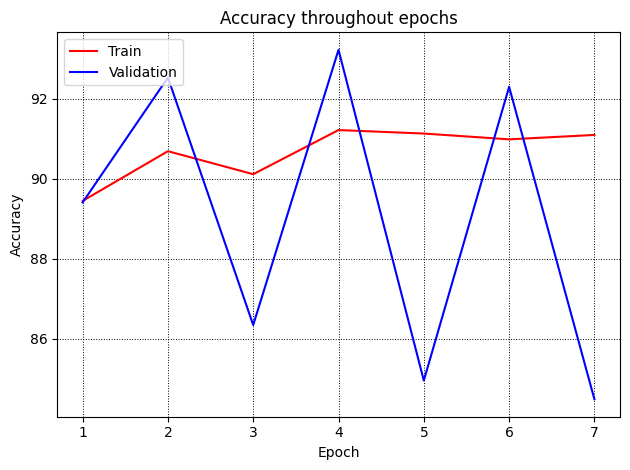

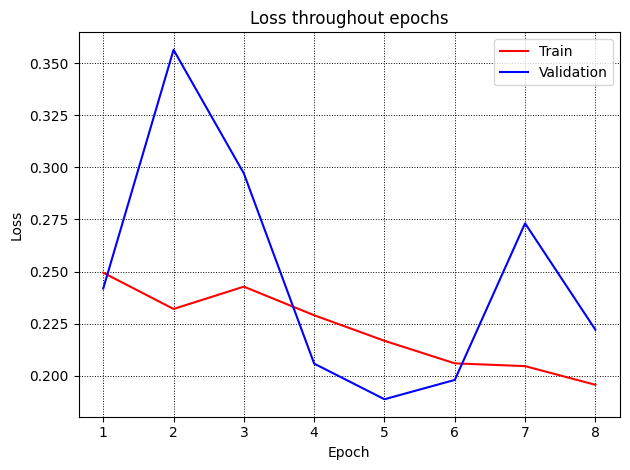

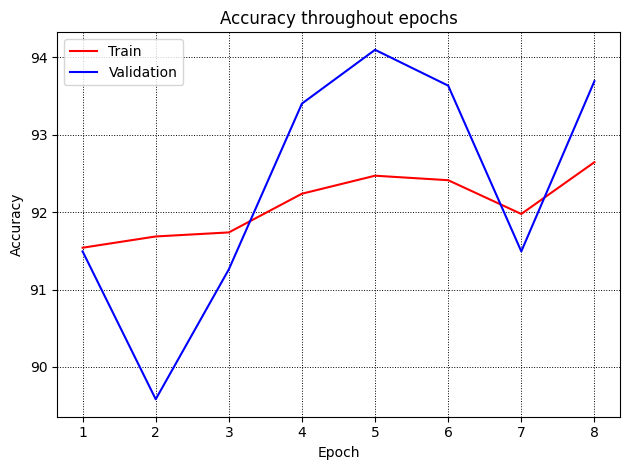

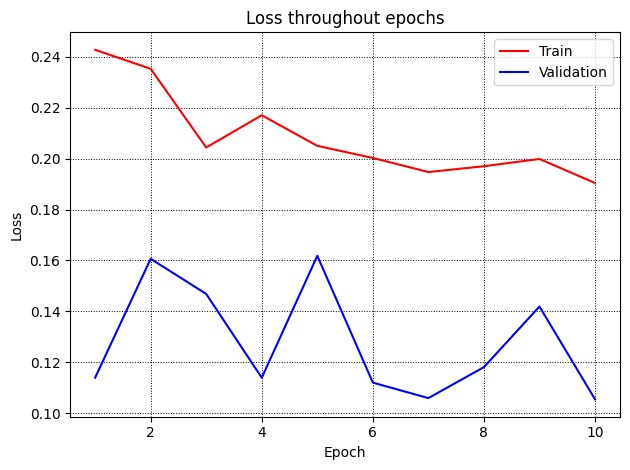

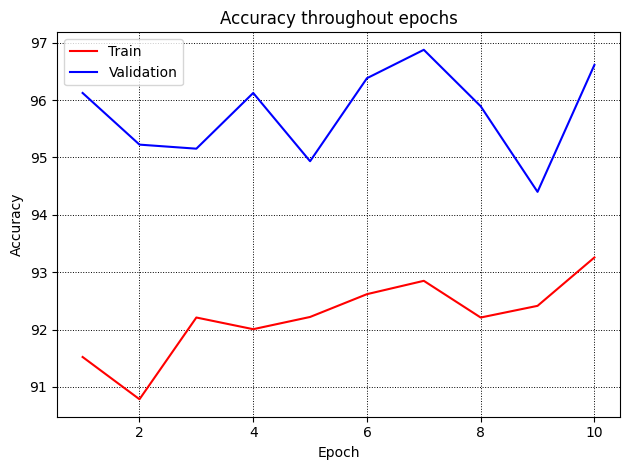

<Figure size 640x480 with 0 Axes>

In [ ]:
best_fold_MyCNN, best_model_ckpt_MyCNN = run_kfold_training(
    train_dataset,
    model=model,
    k_splits=K_SPLITS,
    batch_size=BATCH_SIZE,
    num_epochs=EPOCHS,
    save_root=os.path.join(SAVE_FOLDER),
    loss_fn=LOSS_FN,
    lr=LR_INIT,
    metric_to_select="loss"
)

print(f"🏆 Melhor fold: {best_fold_MyCNN}")
print(f"📁 Melhor modelo: {best_model_ckpt_MyCNN}")

### Validação

In [ ]:
torch.serialization.add_safe_globals([torch.nn.CrossEntropyLoss])

MyCNN_Metrics = test_model(
    model=model,
    test_loader,
    checkpoint_path=best_model_ckpt_MyCNN,
    loss_fn=LOSS_FN,
    partition_name="test",
    metrics_to_comp=[
        "accuracy", "balanced_accuracy", "precision_recall_report",
        "conf_matrix", "plot_conf_matrix", "auc"
    ],
    class_names=["COVID19", "NORMAL", "PNEUMONIA"],
    metrics_options={"save_all_path": os.path.join(SAVE_FOLDER, "metrics_test")},
    apply_softmax=True,
    verbose=True
)

## Treino ImagiNet só camada de classificação

In [ ]:
model_TF = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
num_ftrs = model_TF.fc.in_features
model_TF.fc = nn.Linear(num_ftrs, NUM_CLASSES)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 218MB/s]


INFO:Train-Logger:Starting the training phase
INFO:Train-Logger:Early stopping is set using the number of epochs without improvement
INFO:Train-Logger:The model will be trained from scratch
INFO:Train-Logger:The training will be carry out using 1 GPU:
INFO:Train-Logger:Tesla T4



Iniciando FOLD 1/3

Training...


Epoch 1/10: 100%|#####################################| 215/215 [01:05<00:00,  3.26it/s, loss=0.464]



Evaluating...


100%|###################################################| 54/54 [00:31<00:00,  1.71it/s, loss=0.283]
INFO:Train-Logger:Metrics for epoch 1 out of 10
- Train
-- Loss: 0.464
-- Acc: 81.855
-- Top 2 acc: 97.674

- Validation
-- Loss: 0.283
-- Acc: 90.488
-- Top 2 acc: 99.306
-- Balanced accuracy: 0.887
-- AUC: 0.972

- Training info
-- Early stopping counting: 0 max to stop is 3
-- Current LR: 0.001
-- New best loss: 0.283
-- Best loss so far: 0.283 on epoch 1



...

Training...


Epoch 4/10: 100%|#####################################| 215/215 [01:06<00:00,  3.21it/s, loss=0.256]



Evaluating...


100%|###################################################| 54/54 [00:32<00:00,  1.68it/s, loss=0.145]
INFO:Train-Logger:Metrics for epoch 4 out of 10
- Train
-- Loss: 0.256
-- Acc: 90.320
-- Top 2 acc: 99.535

- Validation
-- Loss: 0.145
-- Acc: 94.907
-- Top 2 acc: 99.653
-- Balanced accuracy: 0.946
-- AUC: 0.991

- Training info
-- Early stopping counting: 3 max to stop is 3
-- Current LR: 0.001
-- Best loss so far: 0.136 on epoch 1

INFO:Train-Logger:The early stop trigger was activated. The validation loss 0.136 did not improved for 3 epochs.The training phase was stopped.


Saving history plots in /results_cv/kfold_1766272521/fold_3/history
Saving history CSVs in /results_cv/kfold_1766272521/fold_3/history


📌 Fold 3 — melhor loss: 0.136

🏆 MELHOR FOLD: 3
🏅 Métrica [loss]: 0.136

🏆 Melhor fold: 3
📁 Melhor modelo: /results_cv/kfold_1766272521/fold_3/best-checkpoint/best-checkpoint.pth


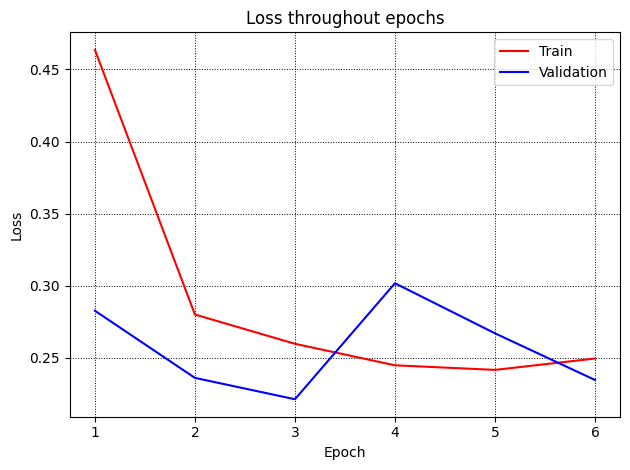

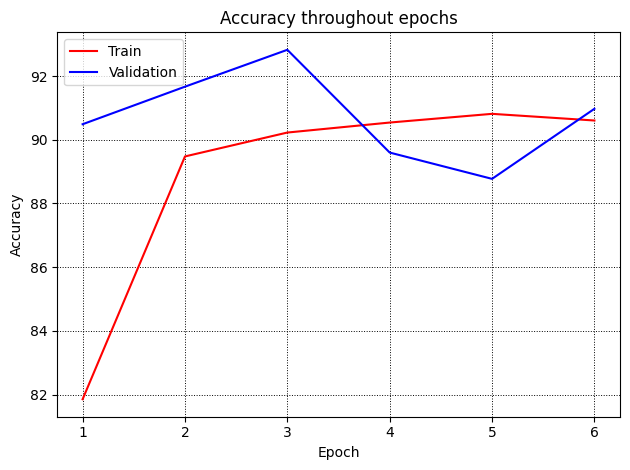

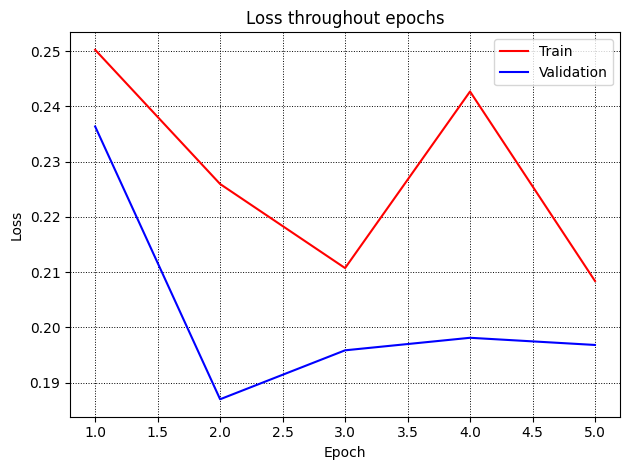

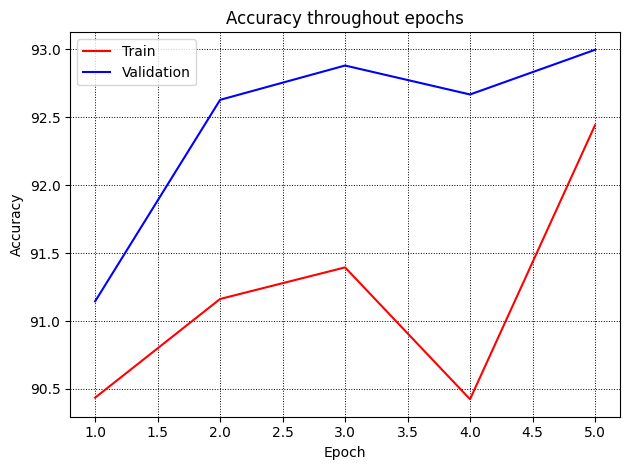

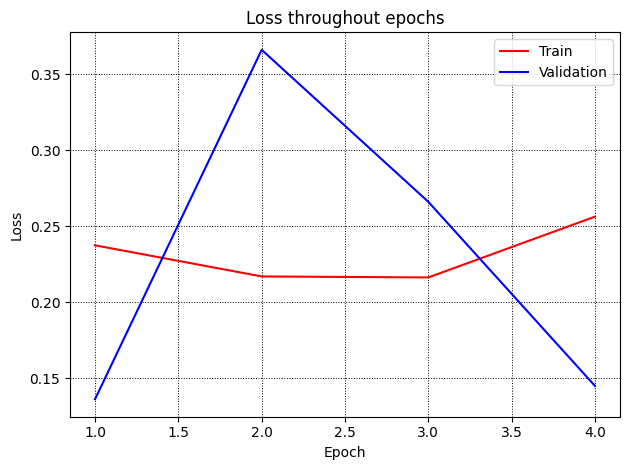

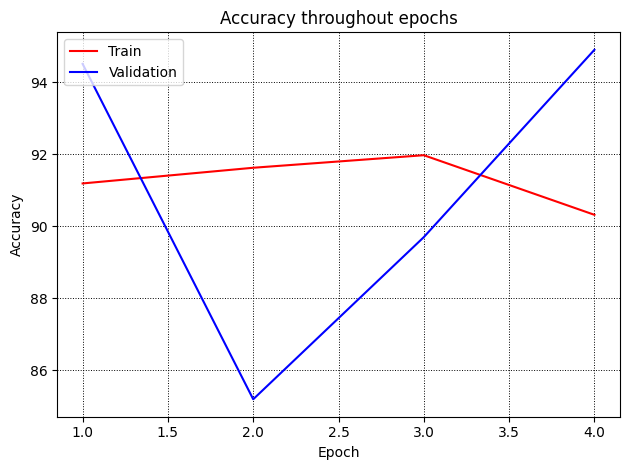

<Figure size 640x480 with 0 Axes>

In [ ]:
SAVE_FOLDER = f"/content/drive/MyDrive/Trab2_redes/results_Parcial_TF/kfold_{int(time.time())}"

best_fold_Parcial_TF, best_model_ckpt_Parcial_TF = run_kfold_training(
    train_dataset,
    model=model_TF,
    k_splits=K_SPLITS,
    batch_size=BATCH_SIZE,
    num_epochs=EPOCHS,
    save_root=os.path.join(SAVE_FOLDER),
    loss_fn=LOSS_FN,
    lr=LR_INIT,
    metric_to_select="loss",
    Parcial_TF=True
)

print(f"🏆 Melhor fold: {best_fold_Parcial_TF}")
print(f"📁 Melhor modelo: {best_model_ckpt_Parcial_TF}")

### Validação

In [ ]:
torch.serialization.add_safe_globals([torch.nn.CrossEntropyLoss])

Parcial_TF_Metrics = test_model(
    model=model_TF,
    test_loader,
    checkpoint_path=best_model_ckpt_Parcial_TF,
    loss_fn=LOSS_FN,
    partition_name="test",
    metrics_to_comp=[
        "accuracy", "balanced_accuracy", "precision_recall_report",
        "conf_matrix", "plot_conf_matrix", "auc"
    ],
    class_names=["COVID19", "NORMAL", "PNEUMONIA"],
    metrics_options={"save_all_path": os.path.join(SAVE_FOLDER, "metrics_test")},
    apply_softmax=True,
    verbose=True
)

## Treino Full Transfer Learning

INFO:Train-Logger:Starting the training phase
INFO:Train-Logger:Early stopping is set using the number of epochs without improvement
INFO:Train-Logger:The model will be trained from scratch
INFO:Train-Logger:The training will be carry out using 1 GPU:
INFO:Train-Logger:Tesla T4



Iniciando FOLD 1/3

Training...


Epoch 1/10: 100%|#####################################| 215/215 [01:04<00:00,  3.31it/s, loss=0.213]



Evaluating...


100%|###################################################| 54/54 [00:33<00:00,  1.63it/s, loss=0.165]
INFO:Train-Logger:Metrics for epoch 1 out of 10
- Train
-- Loss: 0.213
-- Acc: 92.355
-- Top 2 acc: 99.622

- Validation
-- Loss: 0.165
-- Acc: 94.039
-- Top 2 acc: 99.653
-- Balanced accuracy: 0.929
-- AUC: 0.988

- Training info
-- Early stopping counting: 0 max to stop is 3
-- Current LR: 0.001
-- New best loss: 0.165
-- Best loss so far: 0.165 on epoch 1



...

Training...


Epoch 4/10: 100%|#####################################| 215/215 [01:05<00:00,  3.26it/s, loss=0.203]



Evaluating...


100%|###################################################| 54/54 [00:31<00:00,  1.69it/s, loss=0.114]
INFO:Train-Logger:Metrics for epoch 4 out of 10
- Train
-- Loss: 0.203
-- Acc: 92.016
-- Top 2 acc: 99.797

- Validation
-- Loss: 0.114
-- Acc: 95.949
-- Top 2 acc: 99.884
-- Balanced accuracy: 0.953
-- AUC: 0.994

- Training info
-- Early stopping counting: 3 max to stop is 3
-- Current LR: 0.001
-- Best loss so far: 0.101 on epoch 1

INFO:Train-Logger:The early stop trigger was activated. The validation loss 0.101 did not improved for 3 epochs.The training phase was stopped.


Saving history plots in /results_cv/kfold_1766272521/fold_3/history
Saving history CSVs in /results_cv/kfold_1766272521/fold_3/history


📌 Fold 3 — melhor loss: 0.101

🏆 MELHOR FOLD: 3
🏅 Métrica [loss]: 0.101

🏆 Melhor fold: 3
📁 Melhor modelo: /results_cv/kfold_1766272521/fold_3/best-checkpoint/best-checkpoint.pth


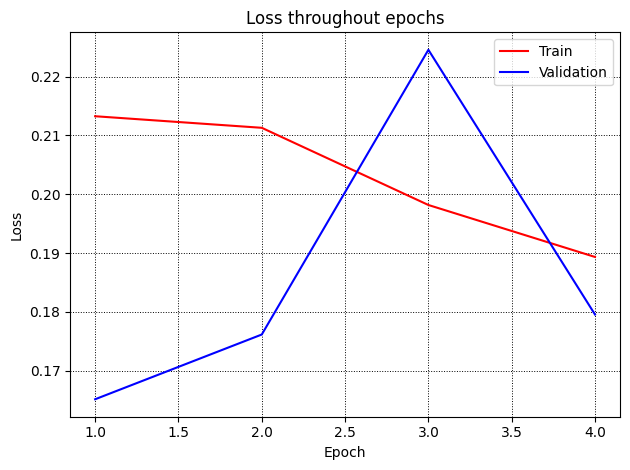

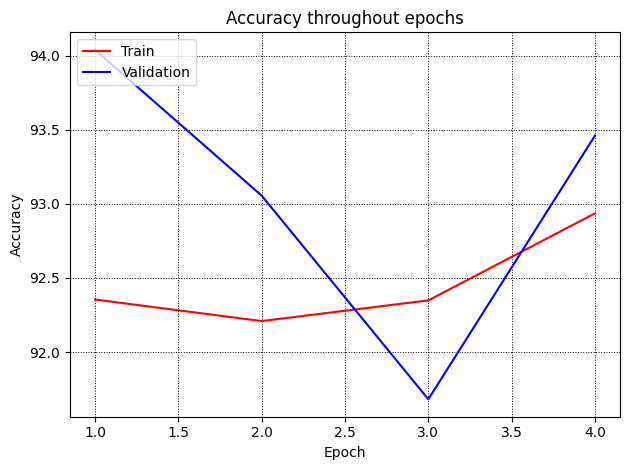

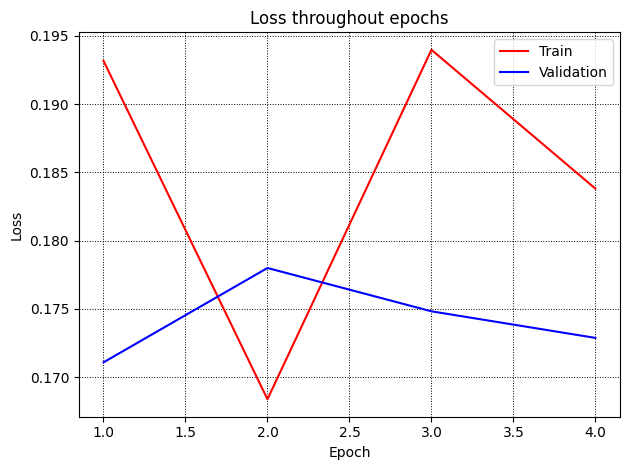

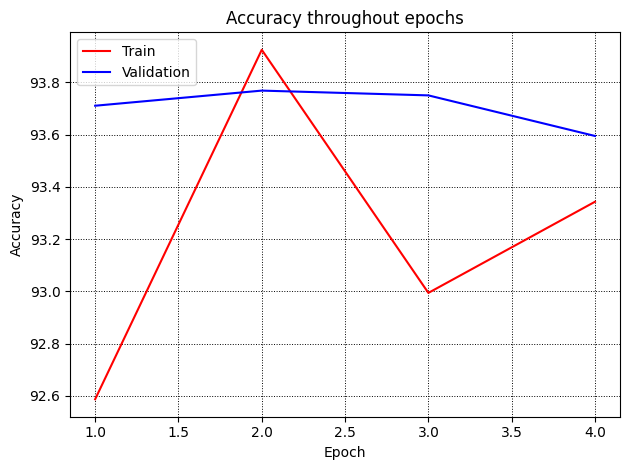

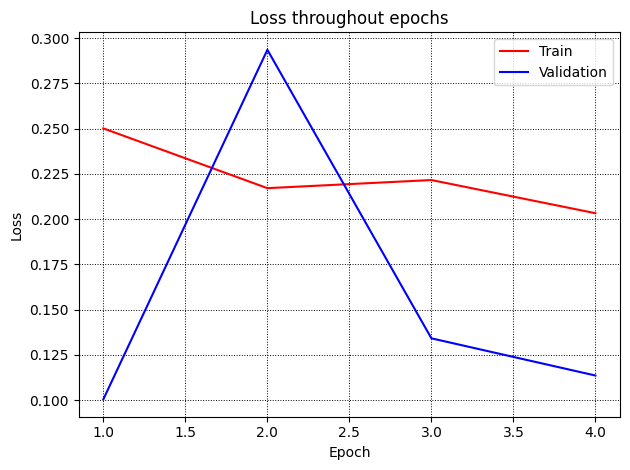

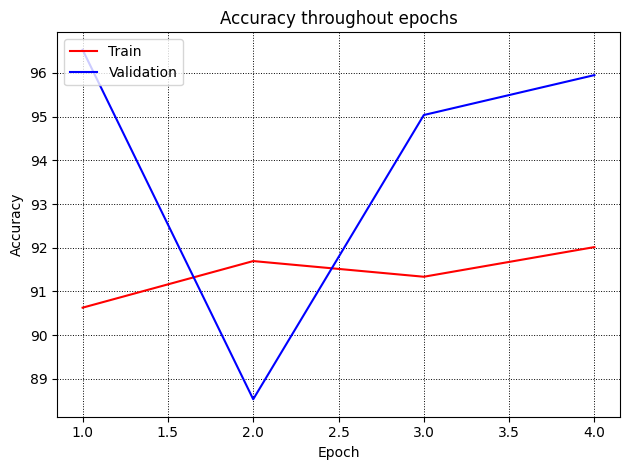

<Figure size 640x480 with 0 Axes>

In [ ]:
SAVE_FOLDER = f"/content/drive/MyDrive/Trab2_redes/results_Full_TF/kfold_{int(time.time())}"

best_fold_Full_TF, best_model_ckpt_Full_TF = run_kfold_training(
    train_dataset,
    model=model_TF,
    k_splits=K_SPLITS,
    batch_size=BATCH_SIZE,
    num_epochs=EPOCHS,
    save_root=os.path.join(SAVE_FOLDER),
    loss_fn=LOSS_FN,
    lr=LR_INIT,
    metric_to_select="loss",
    Full_TF=True
)

print(f"🏆 Melhor fold: {best_fold_Full_TF}")
print(f"📁 Melhor modelo: {best_model_ckpt_Full_TF}")

### Avaliação

In [ ]:
# Agora avalia no TESTE
torch.serialization.add_safe_globals([torch.nn.CrossEntropyLoss])

Full_TF_Metrics = test_model(
    model=model_TF,
    test_loader,
    checkpoint_path=best_model_ckpt_Full_TF,
    loss_fn=LOSS_FN,
    partition_name="test",
    metrics_to_comp=[
        "accuracy", "balanced_accuracy", "precision_recall_report",
        "conf_matrix", "plot_conf_matrix", "auc"
    ],
    class_names=["COVID19", "NORMAL", "PNEUMONIA"],
    metrics_options={"save_all_path": os.path.join(SAVE_FOLDER, "metrics_test")},
    apply_softmax=True,
    verbose=True
)